In [1]:
import sys
sys.path.append("/Users/tdinelli/Documents/GitHub/diffPLOG2TROE")

import matplotlib.pyplot as plt
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from diffPLOG2TROE.rate_constants import FallOff, Plog
from diffPLOG2TROE.plog_refitter import PlogRefitter

## NH2+H = NH3

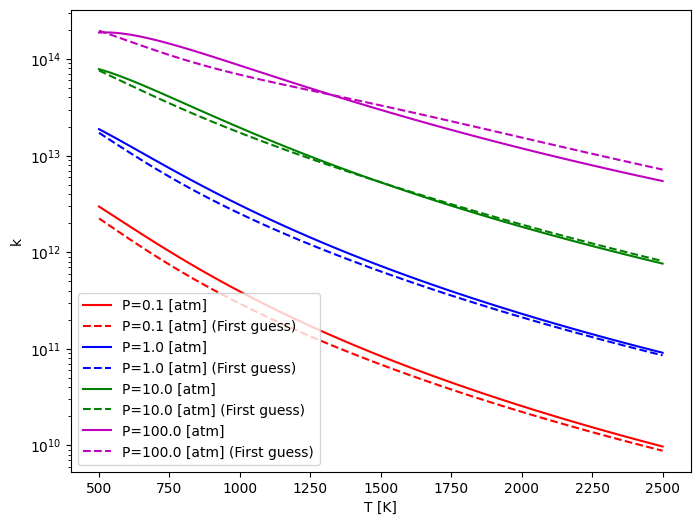

In [2]:
plog = {
    "name": "NH2+H=NH3",
    "type": "plog",
    "rate-constant": {
        "coefficients": [
            [1.00000e-01, 1.21300e+27, -4.95900e+00, 2.80709e+03],
            [1.00000e+00, 5.86700e+27, -4.86700e+00, 3.10796e+03],
            [1.00000e+01, 3.31400e+28, -4.79800e+00, 3.83238e+03],
            [1.00000e+02, 4.51200e+28, -4.56300e+00, 4.72319e+03]
        ]
    }
}
constant = Plog(plog)

# These values are the one computed directly by the refitter class as its shown in the next cells
troe = FallOff(
    name="NH2+H(+M)=NH3(+M)",
    hpl_params=jnp.array([1.500e+14, 0.167, 0.000e+00]),
    lpl_params=jnp.array([9.954e+29, -3.959, 2.807e+03]),
    falloff_params=jnp.array([0.500, 1.050e+03, 3.000e+02, 2.250e+03, 0.]),
    falloff_type=1
)

T_range = jnp.linspace(500, 2500, 100)
P_range = jnp.logspace(jnp.log10(0.1), jnp.log10(100), 100)
P_levels = jnp.array([0.1, 1, 10, 100])

# Let's start by computing the value of the kinetic constant and plotting it
k_plog = constant.kinetic_constant(T_range, P_levels)
k_troe = troe.kinetic_constant(T_range, P_levels)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["r", "b", "g", "m", "c"]

for i, (ki_plog, ki_troe) in enumerate(zip(k_plog, k_troe)):
    ax.plot(T_range, ki_plog, '-', color=colors[i], label=f"P={P_levels[i]} [atm]")
    ax.plot(T_range, ki_troe, '--', color=colors[i], label=f"P={P_levels[i]} [atm] (First guess)")
    
ax.set_yscale("log")
ax.set_xlabel("T [K]")
ax.set_ylabel("k")
ax.legend()
plt.show()

Known that the high pressure limit for this reaction has been measured when we are going to refit its values into a TROE we are going to fix these values consistently

In [3]:
troe_param_config = {
    "A_high": {"optimize": False, "value": 1.50e+14},
    "n_high": {"optimize": False, "value": 0.167},
    "E_high": {"optimize": False, "value": 0.0},
}

refitter = PlogRefitter(
    plog_dict=plog,
    T_range=(500, 2500),
    P_range=(0.1, 100),
    param_config=troe_param_config,
    fitting_mode="single",
    primary_falloff_type="troe",
    log_name="NH2_H__NH3.log"
)
results = refitter.optimize(
    max_iterations=10000,
    uncertainty_factor=0.5,
    uncertainty_type="symmetric",
    tol=1e-10
)

Plog to troe refitter
 Temperature range [K]: (500, 2500)
 Pressure range [atm]: (0.1, 100)
 Loss function: rmsle

Parameters configuration:
  A_low: optimizing from default initial value
  n_low: optimizing from default initial value
  E_low: optimizing from default initial value
  A_high: fixed at 1.50000e+14
  n_high: fixed at 1.67000e-01
  E_high: fixed at 0.00000e+00
  A: optimizing from default initial value
  T3: optimizing from default initial value
  T1: optimizing from default initial value
  T2: optimizing from default initial value

Estimating initial parameters:
Troe parameters
  High pressure limit (A, n, Ea): 1.500e+14, 0.167, 0.000e+00
  Low pressure limit (A, n, Ea): 9.954e+29, -3.959, 2.807e+03
  Troe parameters (A, T3, T1, T2): 0.500, 1.050e+03, 3.000e+02, 2.250e+03


Calculating optimization bounds (uncertainty factor: 0.5)

Bounds for Arrhenius parameters (high pressure limit):
  A_high: fixed at 3.264e+01
  n_high: fixed at 1.670e-01
  E_high: fixed at 0.000e+00



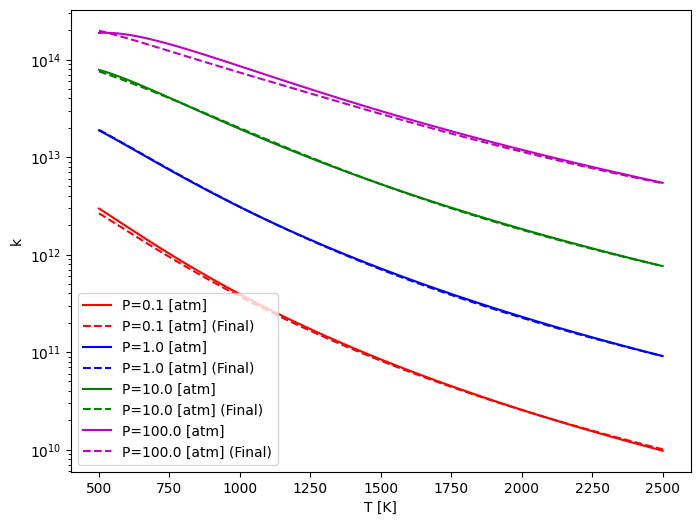

In [4]:
params = results["optimized_params"]
troe = FallOff(
    name="NH2+H(+M)=NH3(+M)",
    lpl_params=jnp.array([jnp.exp(params[0]), params[1], params[2]*1.987]),
    hpl_params=jnp.array([1.50e+14, 0.167, 0]),
    # hpl_params=jnp.array([jnp.exp(params[3]), params[4], params[5]*1.987]),
    falloff_params=jnp.array([params[3], params[4], params[5], params[6], 0]),
    # falloff_params=jnp.array([params[6], params[7], params[8], params[9], 0]),
    falloff_type=1
)

T_range = jnp.linspace(500, 2500, 100)
P_range = jnp.logspace(jnp.log10(0.1), jnp.log10(100), 100)
P_levels = jnp.array([0.1, 1, 10, 100])

# Let's start by computing the value of the kinetic constant and plotting it
k_plog = constant.kinetic_constant(T_range, P_levels)
k_troe = troe.kinetic_constant(T_range, P_levels)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["r", "b", "g", "m", "c"]

for i, (ki_plog, ki_troe) in enumerate(zip(k_plog, k_troe)):
    ax.plot(T_range, ki_plog, '-', color=colors[i], label=f"P={P_levels[i]} [atm]")
    ax.plot(T_range, ki_troe, '--', color=colors[i], label=f"P={P_levels[i]} [atm] (Final)")
    
ax.set_yscale("log")
ax.set_xlabel("T [K]")
ax.set_ylabel("k")
ax.legend()
plt.show()

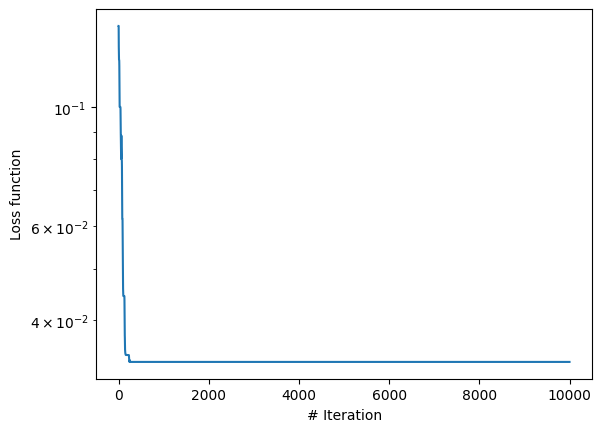

In [5]:
plt.semilogy(results["loss_history"])
plt.xlabel("# Iteration")
plt.ylabel("Loss function")
plt.show()